In [2]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 340.4 kB/s eta 0:00:0000:0100:02

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install kagglehub


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Midterm Quiz 2
**Student Name:** Ruzyl Bryan V. Amora  
**Course/Section:** Computational Thinking with Python

---

## Phase 1: Extract
In this phase, the dataset is retrieved from the source. To follow the requirements, I use the Kaggle API for efficiency.

In [3]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")
print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/RT_IOT2022.csv")

print("Extraction Successful. Dataset Shape:", df.shape)
df.head()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/macbookpro/.cache/kagglehub/datasets/supplejade/rt-iot2022real-time-internet-of-things/versions/3
Extraction Successful. Dataset Shape: (123117, 85)


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


## Phase 2: Transform
In this phase, I clean and prepare the data for analysis. This is crucial for ensuring the accuracy of the statistical summary.

In [4]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

le = LabelEncoder()
df['proto_encoded'] = le.fit_transform(df['proto'])
df['service_encoded'] = le.fit_transform(df['service'])

print("Transformation Complete. New Shape:", df.shape)

Transformation Complete. New Shape: (123117, 87)


## Phase 3: Load, Statistical Analysis, and Visualization

In this final phase, I loaded the cleaned and transformed data to perform a statistical breakdown and create a visual representation of the network traffic.<br>
I used `.describe()` on key columns like `flow_duration` and `fwd_pkts_tot`. 
* **Observation:** The huge difference between the mean and the max values in flow duration suggests that while most network interactions are near-instant, a few specific attacks (like DDoS) stay active for much longer periods.

### Data Visualization:
I generated a horizontal bar chart to show the frequency of each label in the dataset.



#### Why I chose this chart (Horizontal Bar Chart):
* **Readability:** The dataset has long category names like `Metasploit_Brute_Force_SSH`. If I used a vertical bar chart, the labels on the X-axis would overlap or be hard to read. A horizontal chart gives the text plenty of room.
* **Comparison:** It’s very easy to see the "ranking" of attacks at a glance it immediately shows which attacks are the most common in the dataset.

#### Color Pallette:
* **Accessibility:** I chose the `viridis` palette because it is perceptually uniform. This means the colors change at a steady rate, making it easier to distinguish between the bars compared to a single solid color.
* **Professionalism:** It looks more "data-sciencey" than the default basic colors, and it’s also colorblind-friendly, which is a best practice in data visualization.

--- Statistical Summary of Network Traffic ---
       flow_duration   fwd_pkts_tot   bwd_pkts_tot  fwd_data_pkts_tot
count  123117.000000  123117.000000  123117.000000      123117.000000
mean        3.809566       2.268826       1.909509           1.471218
std       130.005408      22.336565      33.018311          19.635196
min         0.000000       0.000000       0.000000           0.000000
25%         0.000001       1.000000       1.000000           1.000000
50%         0.000004       1.000000       1.000000           1.000000
75%         0.000005       1.000000       1.000000           1.000000
max     21728.335578    4345.000000   10112.000000        4345.000000


/var/folders/q7/1g4_b9fn3pd7z_qq7345v6vr0000gn/T/ipykernel_8553/3056271843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Attack_type', order=df['Attack_type'].value_counts().index, palette='viridis')


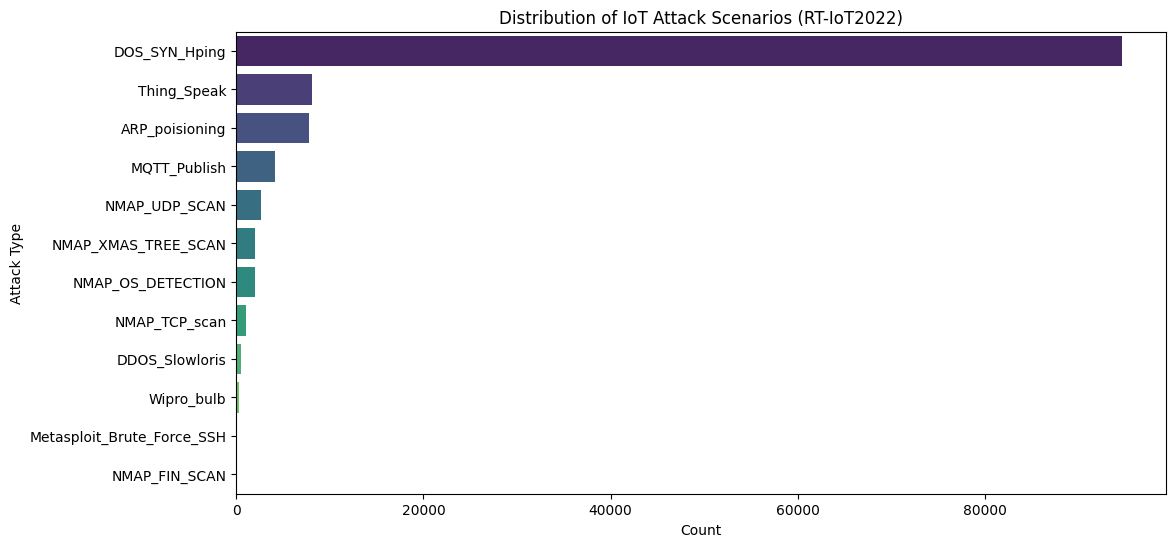

In [5]:
print("--- Statistical Summary of Network Traffic ---")
print(df[['flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot']].describe())

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Attack_type', order=df['Attack_type'].value_counts().index, palette='viridis')
plt.title('Distribution of IoT Attack Scenarios (RT-IoT2022)')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.show()